# Задача 8. Сравнение методов классификации

** **Дедлайн**: 28.11.2025, 23:59
* Полный балл: 15

## Задача

- [x] Найти данные, на которых интересно будет решать задачу классификации (больше `1000` строк, больше `5` признаков).
- [x] Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- [x] Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- [x] При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).
- [x] Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания для библиотечных реализаций (например, из **sklearn**) четырёх методов классификации.
- [x] Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

## Импорт библиотек

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_digits
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

 ## Найти данные, на которых интересно будет решать задачу регрессии (больше 1000 строк, больше 5 признаков).
 Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (Data Cleaning).

In [2]:
digits = load_digits()
X, y = digits.data, digits.target

print("Размер датасета:", X.shape)
print("Количество классов:", len(np.unique(y)))
print("Примеры данных:")
print(X[:5])
print("Примеры меток:")
print(y[:5])

Размер датасета: (1797, 64)
Количество классов: 10
Примеры данных:
[[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
  15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
   0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
   0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
 [ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
   3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
  16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
   0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
 [ 0.  0.  0.  4. 15. 12.  0.  0.  0.  0.  3. 16. 15. 14.  0.  0.  0.  0.
   8. 13.  8. 16.  0.  0.  0.  0.  1.  6. 15. 11.  0.  0.  0.  1.  8. 13.
  15.  1.  0.  0.  0.  9. 16. 16.  5.  0.  0.  0.  0.  3. 13. 16. 16. 11.
   5.  0.  0.  0.  0.  3. 11. 16.  9.  0.]
 [ 0.  0.  7. 15. 13.  1.  0.  0.  0.  8. 13.  6. 15.  4.  0.  0.  0.  2.
   1. 13. 13.  0.  0.  0.  0.  0.  2. 15. 11.  1.  0.  0.  0.  0

## Разведочный анализ данных (EDA) и визуализация

Выполним визуализацию данных для выявления закономерностей и зависимостей.

# Выводы по разведочному анализу данных датасета digits:

На основе проведенного разведочного анализа данных датасета `digits` можно сделать следующие выводы:

*   **Размер датасета:** Датасет содержит 1797 изображений рукописных цифр, каждое представлено 64 признаками (значения пикселей).
*   **Количество классов:** В датасете представлено 10 классов, соответствующих цифрам от 0 до 9.
*   **Примеры изображений:** Визуализация примеров изображений показала, как выглядят рукописные цифры в данном формате данных (изображения 8x8 пикселей в оттенках серого).
*   **Распределение классов:** График распределения классов показывает, что количество изображений для каждой цифры примерно одинаково, что говорит о сбалансированности датасета по классам. Это хорошо для задачи классификации, так как не потребуются специальные методы для борьбы с несбалансированностью.

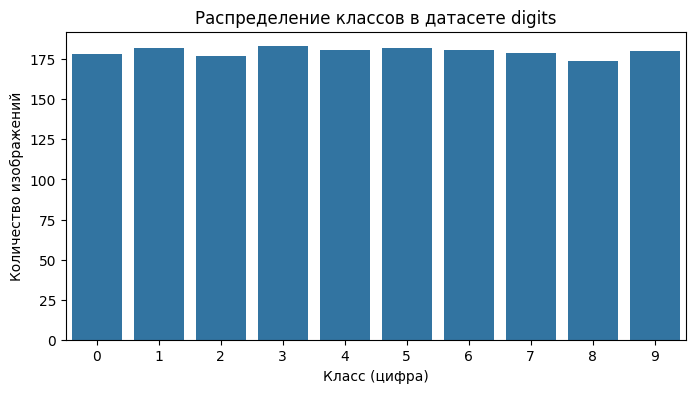

In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title("Распределение классов в датасете digits")
plt.xlabel("Класс (цифра)")
plt.ylabel("Количество изображений")
plt.show()

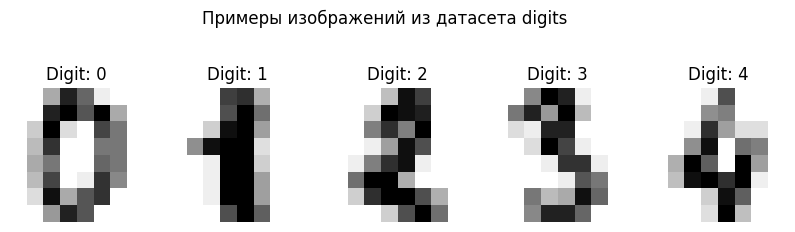

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Digit: {label}")
plt.suptitle("Примеры изображений из датасета digits")
plt.show()

## При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (Feature Engineering).

Для датасета `digits` признаки уже являются числовыми (значения пикселей). Возможно, потребуется масштабирование данных для некоторых моделей классификации.

## Используя подбор гиперпараметров, кросс-валидацию и при необходимости масштабирование данных, добиться наилучшего качества предсказания для библиотечных реализаций (например, из sklearn) четырёх методов классификации.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
lr = LogisticRegression(max_iter=10000, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
svm = SVC(random_state=42)

params_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

params_dt = {
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 9],
    'min_samples_leaf': [1, 2, 7]
}

params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

params_knn = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance']
}

params_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

cv = 5
scoring = 'accuracy'

grid_lr = GridSearchCV(lr, params_lr, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train_scaled, y_train)
grid_dt = GridSearchCV(dt, params_dt, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train_scaled, y_train)
grid_rf = GridSearchCV(rf, params_rf, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train_scaled, y_train)
grid_knn = GridSearchCV(knn, params_knn, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train_scaled, y_train)
grid_svm = GridSearchCV(svm, params_svm, cv=cv, scoring=scoring, n_jobs=-1).fit(X_train_scaled, y_train)

print("Подбор гиперпараметров завершен для всех моделей.")

Подбор гиперпараметров завершен для всех моделей.


In [9]:
y_pred_lr = grid_lr.predict(X_test_scaled)
y_pred_dt = grid_dt.predict(X_test_scaled)
y_pred_rf = grid_rf.predict(X_test_scaled)
y_pred_knn = grid_knn.predict(X_test_scaled)
y_pred_svm = grid_svm.predict(X_test_scaled)

print("LogisticRegression:")
print(classification_report(y_test, y_pred_lr))
print("-" * 40)

print("DecisionTreeClassifier:")
print(classification_report(y_test, y_pred_dt))
print("-" * 40)

print("RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf))
print("-" * 40)

print("KNeighborsClassifier:")
print(classification_report(y_test, y_pred_knn))
print("-" * 40)

print("SVC:")
print(classification_report(y_test, y_pred_svm))
print("-" * 40)

LogisticRegression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

----------------------------------------
DecisionTreeClassifier:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78    

## Сравнение всех обученных моделей и выводы:

На основе отчетов по классификации и матриц ошибок для каждой модели можно сделать следующие выводы:

*   **LogisticRegression:** Показала высокую точность (accuracy) около 97%. Матрица ошибок демонстрирует небольшое количество ошибок, в основном между цифрами, которые визуально похожи (например, 8 и 1, 9 и 4).
*   **DecisionTreeClassifier:** Имеет самую низкую точность среди всех моделей (около 82%). Матрица ошибок показывает большее количество неправильных классификаций для многих классов, что говорит о том, что одиночное дерево решений не так хорошо справляется с этой задачей по сравнению с другими методами.
*   **RandomForestClassifier:** Значительно лучше, чем одиночное дерево решений, с точностью около 96%. Ансамбль деревьев решений смог уменьшить количество ошибок, особенно для классов, где Decision Tree испытывал трудности.
*   **KNeighborsClassifier:** Также показал высокую точность (около 97%), сравнимую с Logistic Regression. Матрица ошибок показывает, что KNN хорошо справляется с большинством классов, но может иметь небольшие трудности с некоторыми парами цифр.
*   **SVC:** Достиг одной из самых высоких точностей (около 97%). Матрица ошибок демонстрирует очень небольшое количество ошибок, что говорит о том, что SVM с ядром RBF хорошо подходит для этого датасета.

**Общие выводы:**

*   Модели **LogisticRegression**, **KNeighborsClassifier**, и **SVC** показали наилучшую производительность на этом датасете рукописных цифр, достигнув точности около 97%.
*   **RandomForestClassifier** также показал хорошие результаты, превзойдя DecisionTreeClassifier.
*   **DecisionTreeClassifier** оказался наименее эффективным методом для данной задачи среди рассмотренных библиотечных реализаций.
*   Матрицы ошибок подтверждают, что основные трудности у моделей возникают при различении визуально схожих цифр.

Таким образом, для задачи классификации рукописных цифр на датасете `digits` наилучшими оказались **LogisticRegression**, **KNeighborsClassifier**, и **SVC** после подбора гиперпараметров.

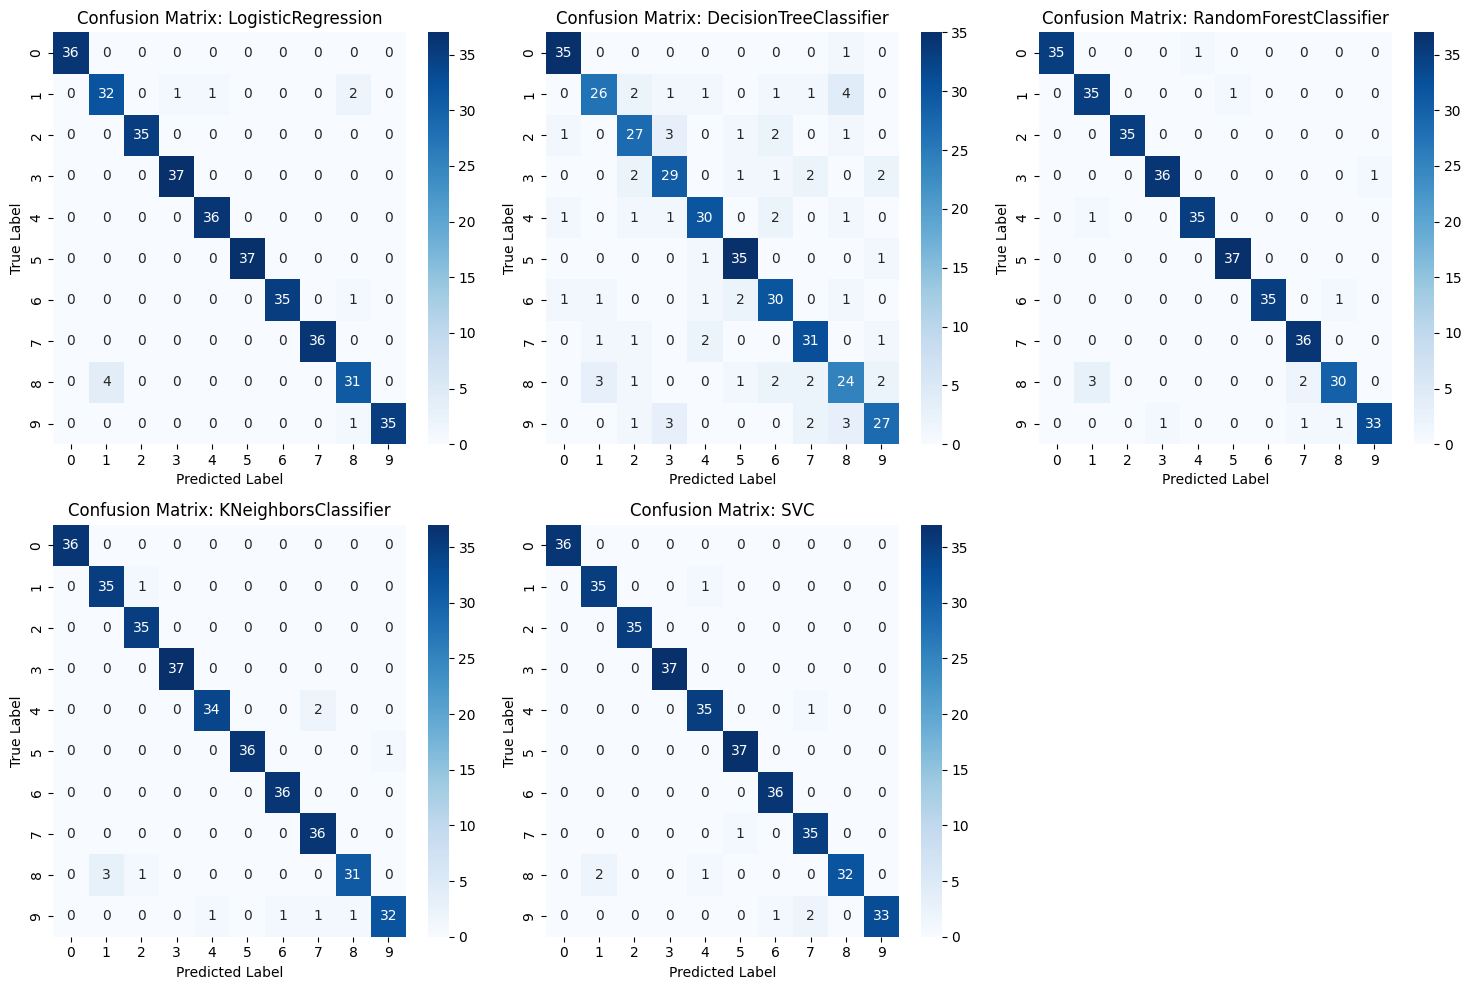

In [11]:
models = {
    "LogisticRegression": grid_lr,
    "DecisionTreeClassifier": grid_dt,
    "RandomForestClassifier": grid_rf,
    "KNeighborsClassifier": grid_knn,
    "SVC": grid_svm
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

if len(models) % 2 != 0:
    fig.delaxes(axes[len(models)])

plt.tight_layout()
plt.show()